In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [91]:
# Load the Titanic dataset
df = sns.load_dataset("titanic")

# Display the first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [92]:
# Check the dataset dimensions
print("Rows and columns:", df.shape)

# Check column names
print("\nColumns:")
print(df.columns.tolist())

Rows and columns: (891, 15)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [93]:
# Basic information about the dataset
print("Dataset Information:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Missing Values:
survived         0
pclass           0
sex

In [94]:
# Summary statistics for numerical columns
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [95]:
# Median of numerical columns
df.median(numeric_only=True)

,0
survived,0.0000
pclass,3.0000
age,28.0000
sibsp,0.0000
parch,0.0000
fare,14.4542
adult_male,1.0000
alone,1.0000


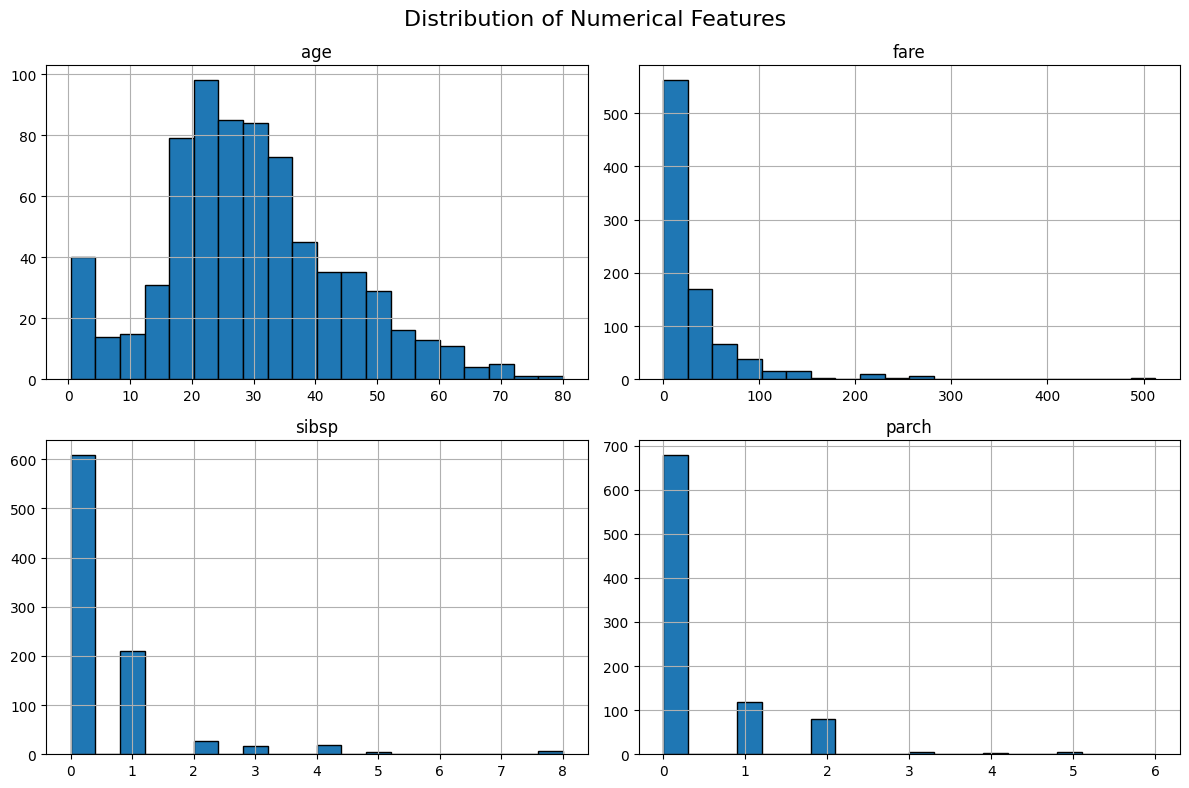

In [96]:
# Histograms for numerical features

numeric_columns = ['age', 'fare', 'sibsp', 'parch']

df[numeric_columns].hist(
    figsize=(12, 8),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

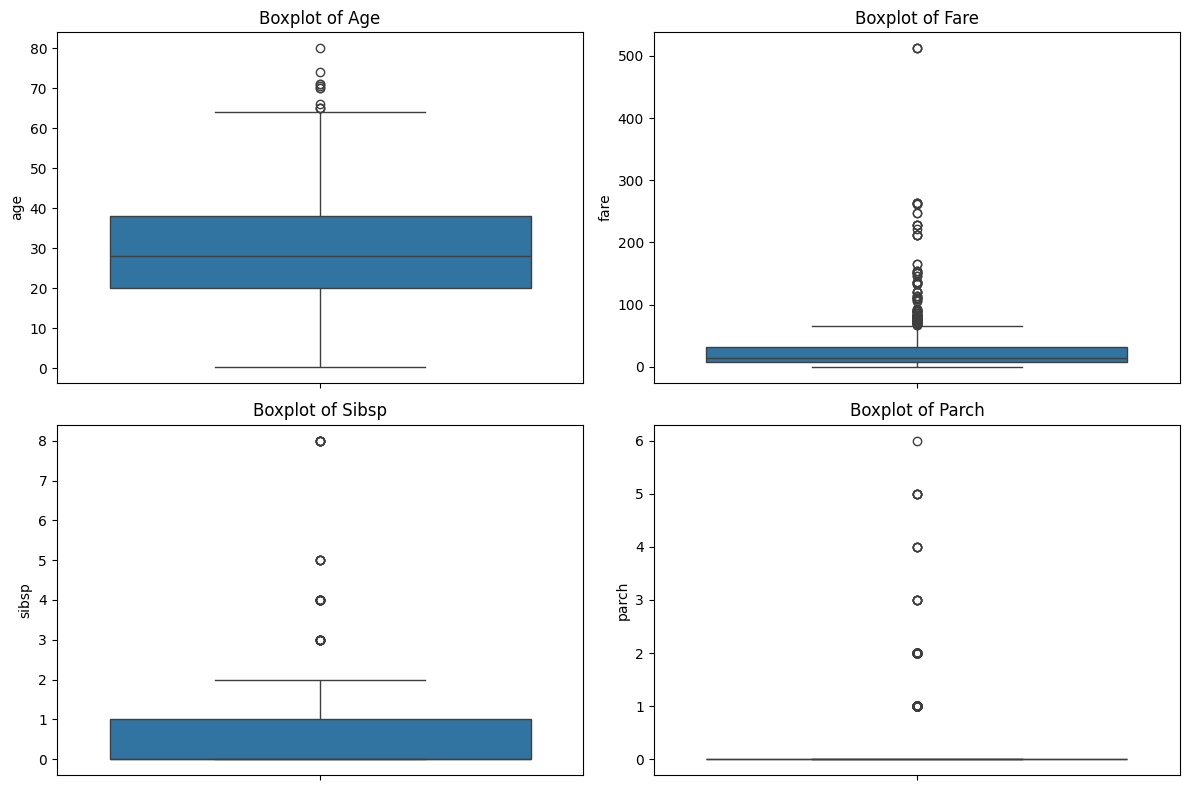

In [97]:
# Boxplots for numerical features

plt.figure(figsize=(12, 8))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[column])
    plt.title(f"Boxplot of {column.capitalize()}")

plt.tight_layout()
plt.show()

In [98]:
# Select numerical columns for correlation analysis
correlation_data = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']]

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

# Display the correlation matrix
print(correlation_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.338481 -0.077221 -0.035322  0.081629  0.257307
pclass   -0.338481  1.000000 -0.369226  0.083081  0.018443 -0.549500
age      -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067
sibsp    -0.035322  0.083081 -0.308247  1.000000  0.414838  0.159651
parch     0.081629  0.018443 -0.189119  0.414838  1.000000  0.216225
fare      0.257307 -0.549500  0.096067  0.159651  0.216225  1.000000


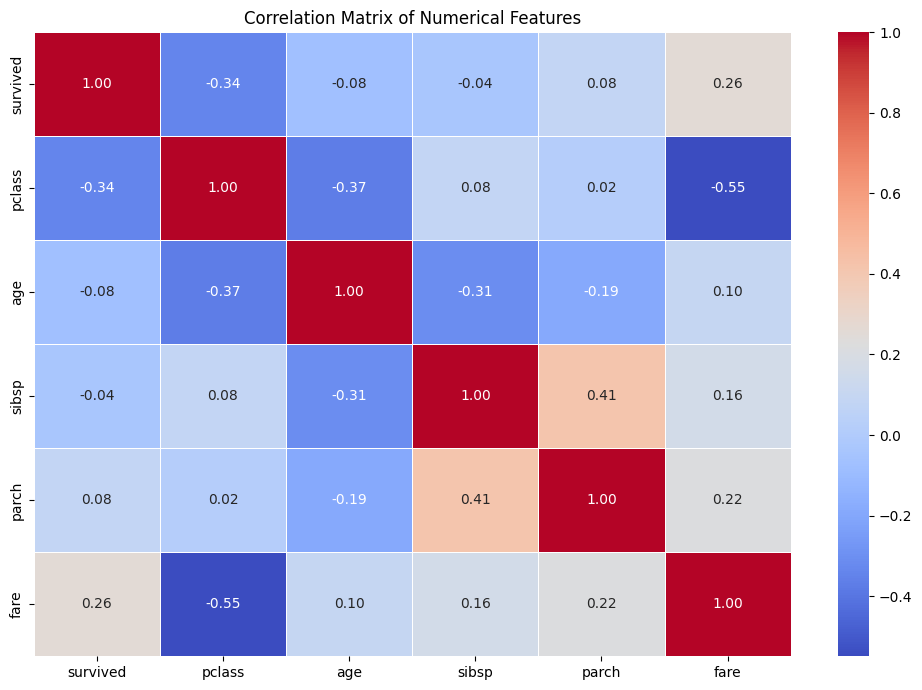

In [99]:
# Visualize the correlation matrix

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

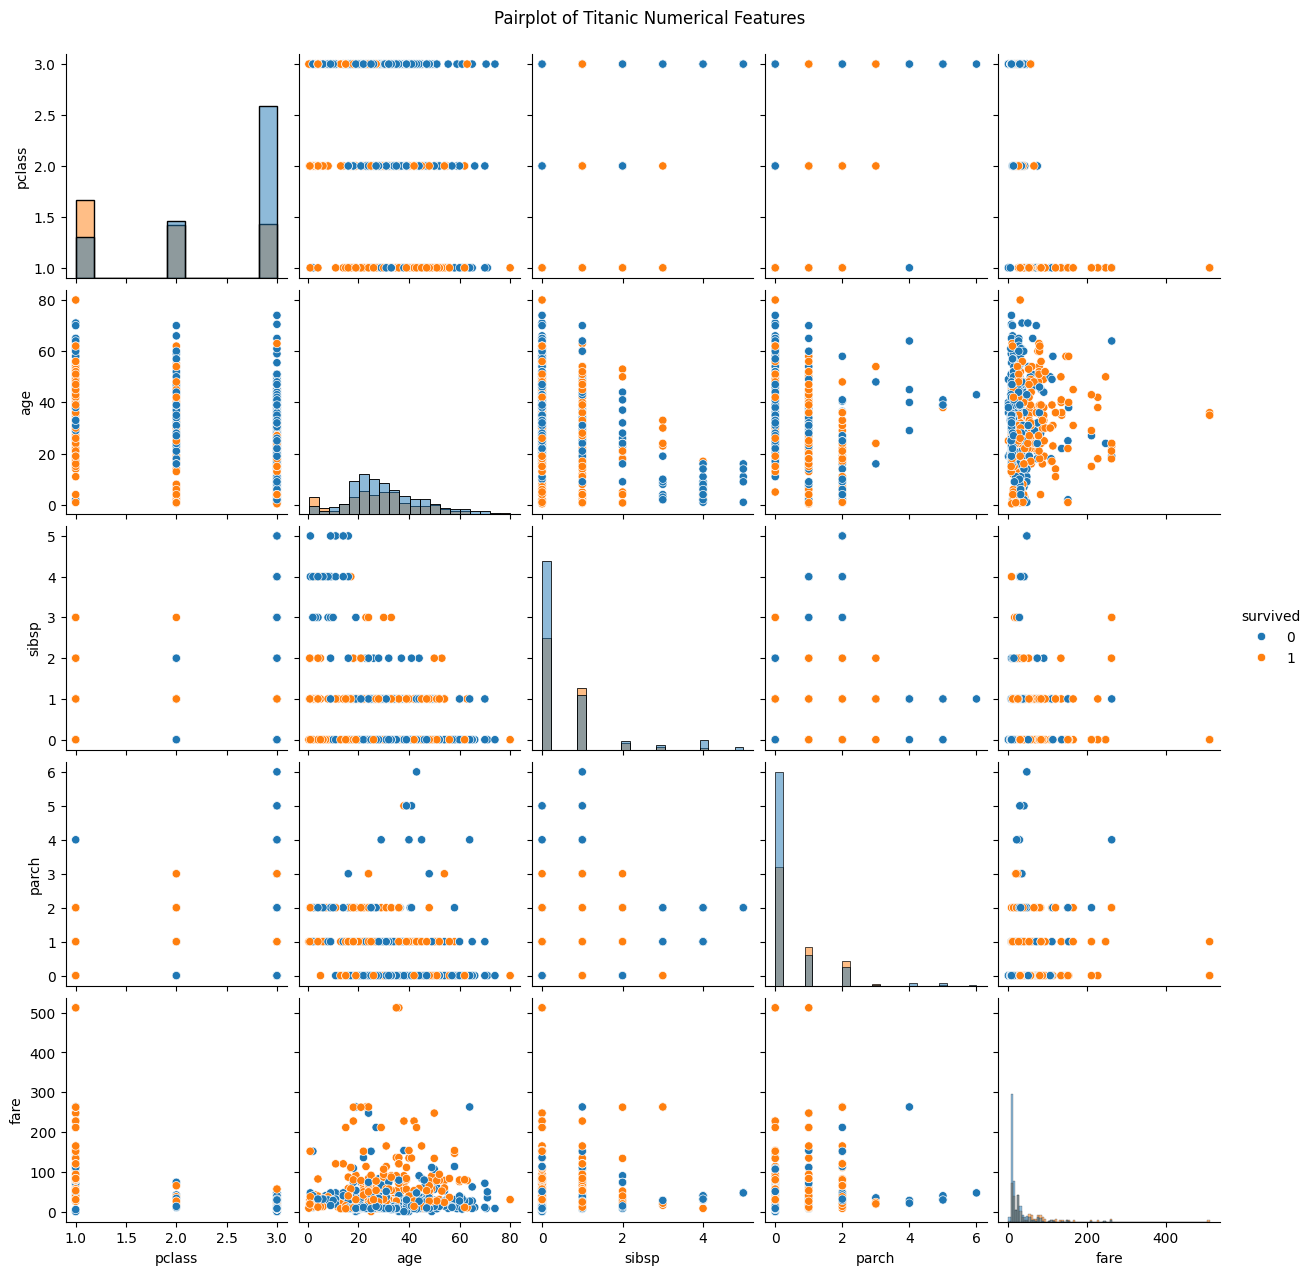

In [100]:
# Create a pairplot to visualize relationships between features

pairplot_data = df[
    ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
].dropna()

sns.pairplot(
    pairplot_data,
    hue='survived',
    diag_kind='hist'
)

plt.suptitle(
    "Pairplot of Titanic Numerical Features",
    y=1.02
)

plt.show()

Survival Rate by Gender:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


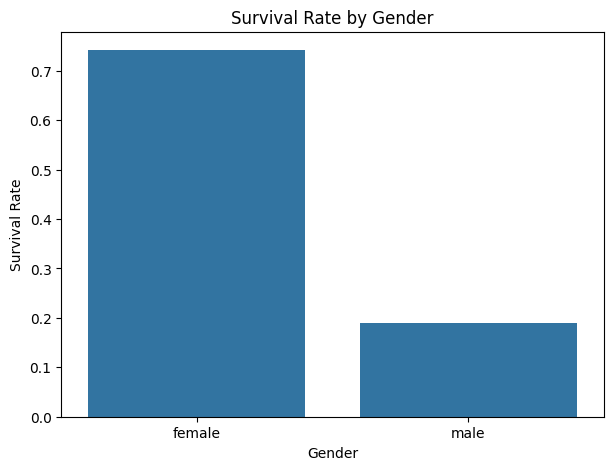

In [101]:
# Survival rate by gender

gender_survival = df.groupby('sex')['survived'].mean()

print("Survival Rate by Gender:")
print(gender_survival)

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_survival.index, y=gender_survival.values)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

Survival Rate by Passenger Class:
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


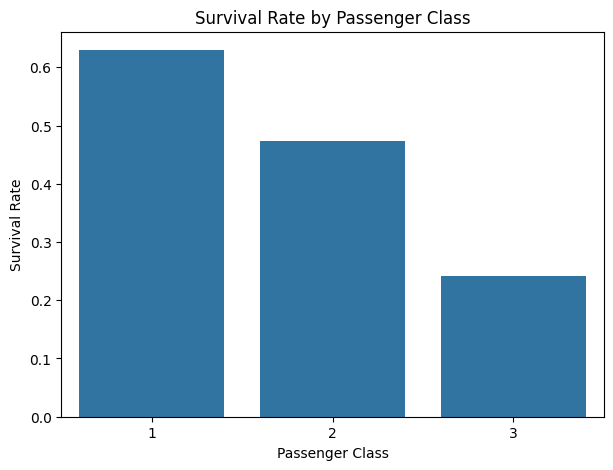

In [102]:
# Survival rate by passenger class

class_survival = df.groupby('pclass')['survived'].mean()

print("Survival Rate by Passenger Class:")
print(class_survival)

plt.figure(figsize=(7, 5))
sns.barplot(x=class_survival.index, y=class_survival.values)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

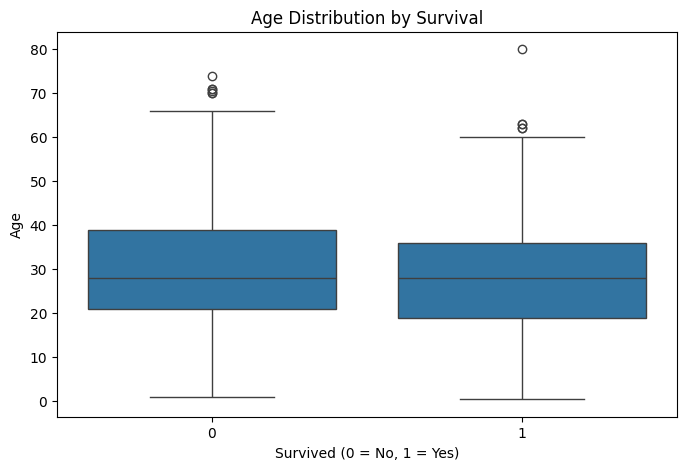

In [103]:
# Compare age distribution by survival

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='survived',
    y='age'
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

# EDA Findings and Insights

## 1. Dataset Overview

The Titanic dataset contains information about passengers, including their survival status, passenger class, age, gender, family relationships, and fare.

The dataset was examined using descriptive statistics and visualizations to understand its structure, distributions, relationships, and potential anomalies.

## 2. Numerical Feature Distributions

Histograms were used to understand the distribution of numerical variables such as age, fare, number of siblings/spouses (`sibsp`), and number of parents/children (`parch`).

- Age shows the distribution of passenger ages.
- Fare shows the distribution of ticket prices and contains some unusually high values.
- `sibsp` and `parch` show how many family members passengers had aboard the ship.

## 3. Outliers

Boxplots were used to identify potential outliers.

The fare variable contains noticeable high-value observations compared with most passengers. These observations may represent passengers who paid substantially higher ticket prices.

## 4. Correlation Analysis

A correlation matrix was created to examine relationships between numerical features.

The heatmap helps identify features that have positive, negative, or weak linear relationships with each other.

Correlation does not necessarily imply causation.

## 5. Survival Patterns

Survival rates were compared across gender and passenger class.

The analysis shows that survival was not equally distributed across these groups. The survival-rate visualizations help identify differences in survival between passenger categories.

Age distributions were also compared between survivors and non-survivors using a boxplot.

## 6. Overall Conclusion

Exploratory Data Analysis helped identify important patterns, distributions, relationships, and potential outliers in the Titanic dataset.

The analysis demonstrates how descriptive statistics and visualization can be used to understand a dataset before applying machine-learning models.